## HR Employee Attrition Prediction and Analysis

This project analyzes data from 1,470 employees to better understand why people leave the organization and what can be done to reduce employee turnover. The overall attrition rate in the dataset is 16.1%, which represents a meaningful business challenge when considering hiring and training costs.

By combining exploratory data analysis, feature engineering, and machine learning techniques, we identified several clear patterns behind employee attrition. The strongest drivers of turnover are overtime work, lower compensation, and the absence of equity-based incentives, with some job roles experiencing attrition rates of up to 47%. These insights highlight where management attention and policy changes can have the greatest impact.

From a financial perspective, employee turnover is expensive. Using industry estimates of 50-100%, approximately $3 to replace a single employee, the loss of 237 employees translates to an annual cost of approximately $9.2–$18.5 million. Based on our analysis, implementing targeted retention strategies could reduce attrition by 30–40%, resulting in potential savings of $2.8–$5.5 or $3.7-$7.4 million per year.

## 1. Business Problem

Employee attrition is more than an HR issue. It directly affects productivity, team morale, and operational costs. When employees leave, organizations lose experience and must invest significant time and money into recruiting and training replacements.

The goal of this analysis is to help the organization:

* Identify employees who are at higher risk of leaving
* Understand the key reasons behind attrition
* Design focused and data-driven retention strategies
* Reduce long-term recruitment and training expenses

### Dataset Overview

* **Source:** IBM HR Analytics Employee Attrition Dataset
* **Size:** 1,470 employee records
* **Features:** 35 variables covering demographics, job roles, compensation, and satisfaction metrics
* **Target Variable:** Attrition (Yes/No)
* **Overall Attrition Rate:** 16.1%

## 2. Methodology

### 2.1 Data Loading and Initial Exploration

The first step was to load the dataset and understand its overall structure. We reviewed the number of records, feature types, and summary statistics to assess data quality and reliability.

Key observations from this initial analysis include:

* The dataset contains 1,470 employees across 35 features
* No missing values were found, indicating strong data quality
* No duplicate records were detected
* Employee ages range from 18 to 60 years, with an average age of 37
* Monthly income ranges from $1,009 to $19,999, with an average of $6,503

In [13]:
# Section 1: Data Loading And Initial Exploration
# Loading the employee attrition dataset and performing initial exploration to understand the structure, data types, and basic statistics of our data.

# Importing of libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings

warnings.filterwarnings('ignore')

# Reading the Excel file
employee_data = pd.read_excel('WA_Fn-UseC_-HR-Employee-Attrition.xlsx')

# Displaying first 5 rows
print("First 5 rows:")
print(employee_data.head())

# Checking the shape of the dataset
print("\nDataset shape:", employee_data.shape)
print("Number of rows:", employee_data.shape[0])
print("Number of columns:", employee_data.shape[1])

# Displaying all column names
print("\nColumn names:")
print(employee_data.columns.tolist())

# Checking data types of each column
print("\nData types:")
print(employee_data.dtypes)

# Getting basic statistics for numerical columns
print("\nBasic statistics:")
print(employee_data.describe())
print("Income:")
print(employee_data['MonthlyIncome'].sort_values())
print("Mean:", employee_data['MonthlyIncome'].mean())

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionL

* The dataset includes 1,470 employees described by 35 different features
* There are no missing values, which means the data is clean and reliable for analysis
* The features include a combination of numerical variables such as age and income and categorical variables such as department and job role
* The main outcome we are trying to predict is employee attrition, recorded as a simple Yes/No value

In [14]:
# Section 2: Data Cleaning
# Identifying and resolving data quality issues to ensure our analysis is based on clean, reliable data. This includes handling missing values, duplicates, and removing irrelevant features.

# Checking for missing values
print("Missing values per column:")
print(employee_data.isnull().sum())

# Checking for duplicates
print("\nNumber of duplicate:", employee_data.duplicated().sum())

# Identifying columns with zero variance
print("\nColumns with zero variance:")
print(employee_data.nunique())

# Dropping useless columns because they are not used for our calcualation and do not give any valuable insights
columns_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
employee_data = employee_data.drop(columns=columns_to_drop)

print("\nColumns dropped:", columns_to_drop)
print("New shape:", employee_data.shape)

# Checking for outliers using IQR
print("\nChecking for potential outliers in numerical columns:")
numerical_cols = employee_data.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    Q1 = employee_data[col].quantile(0.25)
    Q3 = employee_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = employee_data[(employee_data[col] < lower_bound) | (employee_data[col] > upper_bound)]

    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} potential outliers")

# Cleaned data summary
print("\nCleaned dataset info:")
print(f"Shape: {employee_data.shape}")
print(f"Columns: {employee_data.columns.tolist()}")

Missing values per column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurren

### Data Cleaning Decisions

* EmployeeCount, StandardHours, and Over18 were removed because they contain the same value for every employee and therefore provide no useful information for analysis.
* EmployeeNumber was also dropped, as it is simply an identification field and does not help predict employee attrition.

Potential outliers were identified across 10 numerical variables using the Interquartile Range (IQR) method. These data points were intentionally kept in the dataset because:

* They reflect realistic employee scenarios, such as high-income earners or employees with long tenure
* There was no evidence of data entry errors
* Removing them could weaken the model’s ability to learn real-world patterns and generalize effectively

After cleaning, the dataset contains 1,470 rows and 31 columns, making it well-prepared for further analysis and modeling.

## Section 3: Feature Engineering
Creating new features from existing data to capture complex relationships and improve model performance. Feature engineering often provides more value than complex algorithms.
#### Derived Features
Three additional features were created to better capture employee behavior and improve the model’s ability to predict attrition. TotalSatisfaction aggregates multiple satisfaction-related variables into a single score, providing a more comprehensive measure of overall employee sentiment. WorkLifeImbalance identifies employees who both work overtime and report poor work–life balance, highlighting a high-risk group for burnout and turnover. Finally, YearsPerPromotion reflects the pace of career progression, where higher values indicate slower advancement and potentially greater dissatisfaction. Together, these features provide more meaningful and interpretable insights than the original variables alone.


In [15]:
print("\n" + "=" * 50)
print("Feature Engineering: Creating Derived features")
print("=" * 50)

# Feature 1: Total Satisfaction Score
employee_data['TotalSatisfaction'] = (employee_data['JobSatisfaction'] +
                           employee_data['EnvironmentSatisfaction'] +
                           employee_data['RelationshipSatisfaction'] +
                           employee_data['WorkLifeBalance'])

print("\n1. Total Satisfaction Score ")
print(f"Range: {employee_data['TotalSatisfaction'].min()} to {employee_data['TotalSatisfaction'].max()}")
print(f"Mean: {employee_data['TotalSatisfaction'].mean():.2f}")

# Feature 2: Work-Life Imbalance Flag
employee_data['WorkLifeImbalance'] = ((employee_data['OverTime'] == 'Yes') &
                           (employee_data['WorkLifeBalance'] <= 2)).astype(int)

print("\n2. Work-Life Imbalance Flag")
print(f"Employees with work-life imbalance: {employee_data['WorkLifeImbalance'].sum()}")
print(f"Percentage: {(employee_data['WorkLifeImbalance'].sum() / len(employee_data) * 100):.2f}%")

# Feature 3: Years Per Promotion
employee_data['YearsPerPromotion'] = employee_data['YearsAtCompany'] / (employee_data['YearsSinceLastPromotion'] + 1)

print("\n3. Years Per Promotion Created")
print(f"Mean years per promotion: {employee_data['YearsPerPromotion'].mean():.2f}")

print("\n" + "=" * 50)
print(f"Original features after cleaning: 31")
print(f"New features added: 3")
print(f"Total features now: {employee_data.shape[1]}")
print("=" * 50)


Feature Engineering: Creating Derived features

1. Total Satisfaction Score 
Range: 4 to 16
Mean: 10.92

2. Work-Life Imbalance Flag
Employees with work-life imbalance: 126
Percentage: 8.57%

3. Years Per Promotion Created
Mean years per promotion: 3.12

Original features after cleaning: 31
New features added: 3
Total features now: 34


**1. TotalSatisfaction. It's range: 4–16, mean: 10.92**
Instead of looking at multiple satisfaction scores separately, we combined four related measures into a single TotalSatisfaction score. This makes the data easier to interpret while still capturing how employees feel overall. A single, well-designed metric provides a clearer picture of general employee sentiment than several overlapping variables.

**2. WorkLifeImbalance with approximately 120 employees flagged, 8.57%**
This feature highlights employees who are working overtime while also reporting poor work–life balance. Together, these two factors point to a high risk of burnout.
The results clearly show its importance: employees in this group have an attrition rate of 33.3%, compared to 14.5% for everyone else, a difference of nearly 19 percentage points. This makes WorkLifeImbalance one of the strongest warning signals in the analysis.

**3. YearsPerPromotion. It's mean: 3.12 years**
YearsPerPromotion captures how quickly employees move forward in their careers. Higher values indicate slower advancement, which can lead to frustration and disengagement over time. This feature helps identify employees who may feel stuck or overlooked, even if other aspects of their job seem satisfactory.

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


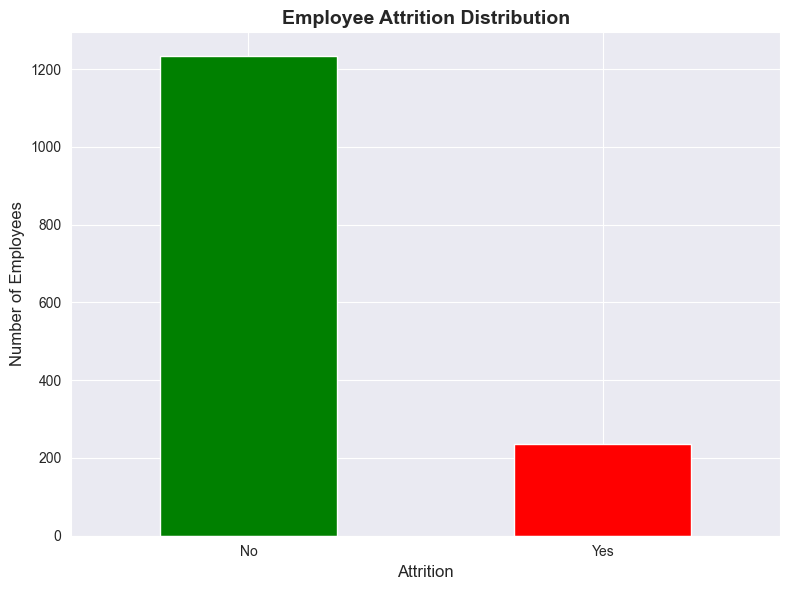

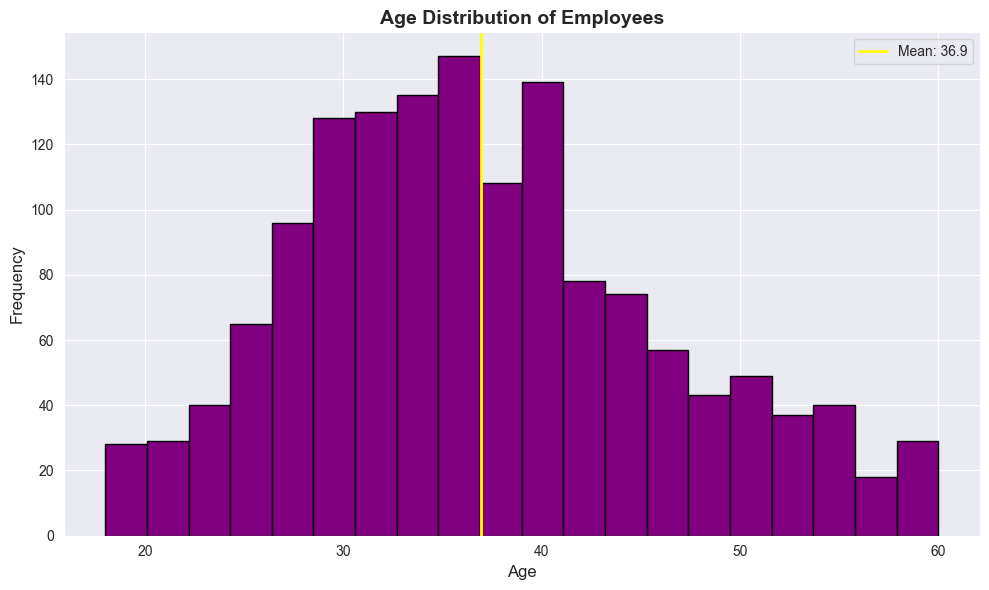

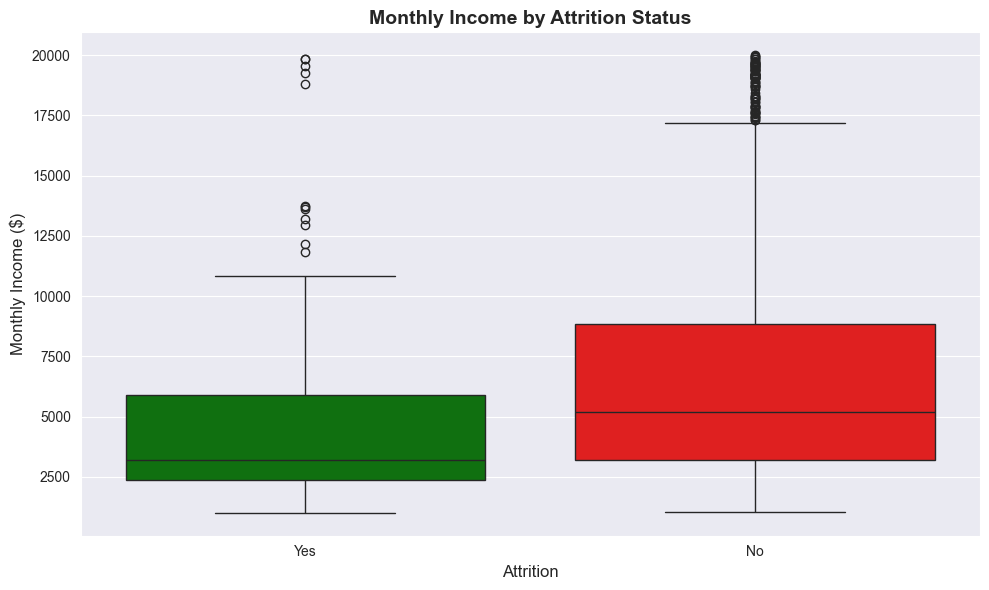

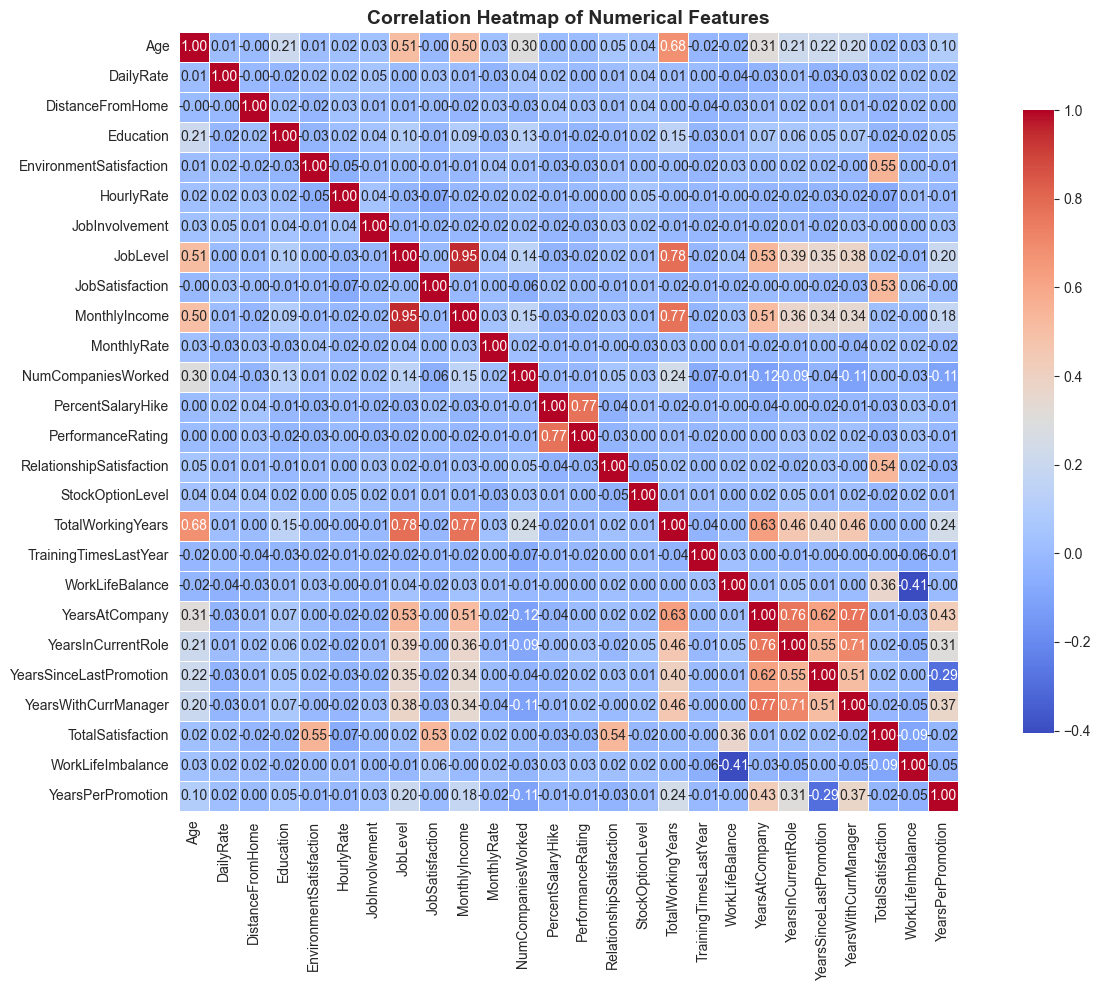

In [16]:
# Section 4: Exploratory Data Analysis (EDA)
# Visualizing data distributions and relationships to uncover patterns, trends, and insights that inform our modeling strategy and business recommendations.
"""
Visualization Goals:
1. Understand target variable distribution
2. Explore demographic characteristics
3. Identify relationships between features and attrition
4. Detect correlations between numerical variables

Key Insights to Discover:
What percentage of employees leave?
Which age groups are most at risk?
Does income affect attrition?
Which features are highly correlated?
"""

# Visualization 1: Attrition Distribution
print("Attrition Distribution:")
print(employee_data['Attrition'].value_counts())
print("\nAttrition Percentage:")
print(employee_data['Attrition'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 6))
employee_data['Attrition'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Employee Attrition Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualization 2: Age Distribution
plt.figure(figsize=(10, 6))
plt.hist(employee_data['Age'], bins=20, color='purple', edgecolor='black')
plt.title('Age Distribution of Employees', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(employee_data['Age'].mean(), color='yellow', linestyle='-', linewidth=2, label=f"Mean: {employee_data['Age'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

# Visualization 3: Monthly Income by Attrition
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=employee_data, hue='Attrition', palette=['green', 'red'], legend=False)
plt.title('Monthly Income by Attrition Status', fontsize=14, fontweight='bold')
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Monthly Income ($)', fontsize=12)
plt.tight_layout()
plt.show()

# Visualization 4: Correlation Heatmap
plt.figure(figsize=(14, 10))
numerical_data = employee_data.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_data.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**1. Class Imbalance (83.9% No, 16.1% Yes)**
The dataset is heavily skewed toward employees who stayed, with only 16.1% labeled as attrition cases.

**2. Age Distribution**
Most employees fall between 28 and 43 years old, with an average age of 36.9 years. Early analysis shows that younger employees are more likely to leave, suggesting that retention challenges may be stronger early in an employee’s career.

**3. The Compensation Gap**
A clear difference appears when comparing income levels between employees who stayed and those who left. Employees who exited the company tend to earn significantly less, as shown in the box plot. The lower median income among leavers highlights compensation as a key driver of attrition and a critical variable for predictive modeling.

**4. Correlation Patterns**
Strong correlations were observed between variables such as Age and Monthly Income, as well as Total Working Years and Income, which aligns with expected career progression patterns. However, most features show only weak linear correlations with attrition, indicating that non-linear models are better suited to capture the complex factors influencing employee turnover.


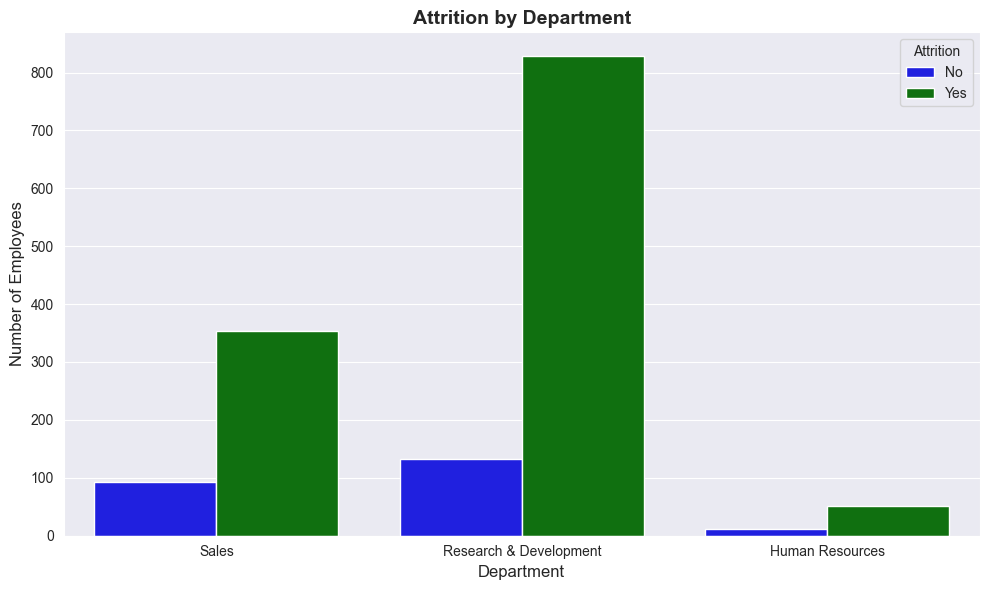

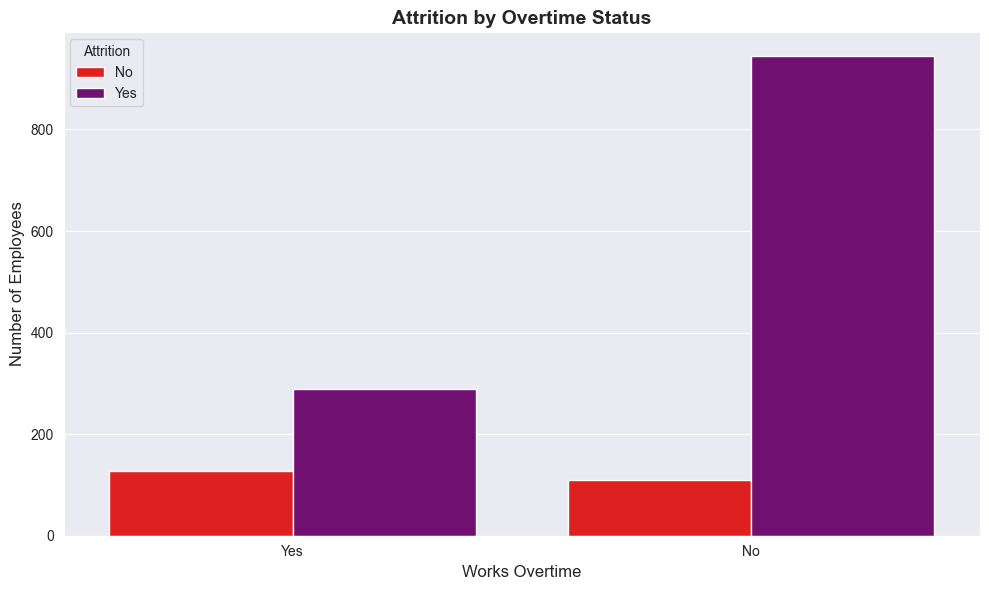

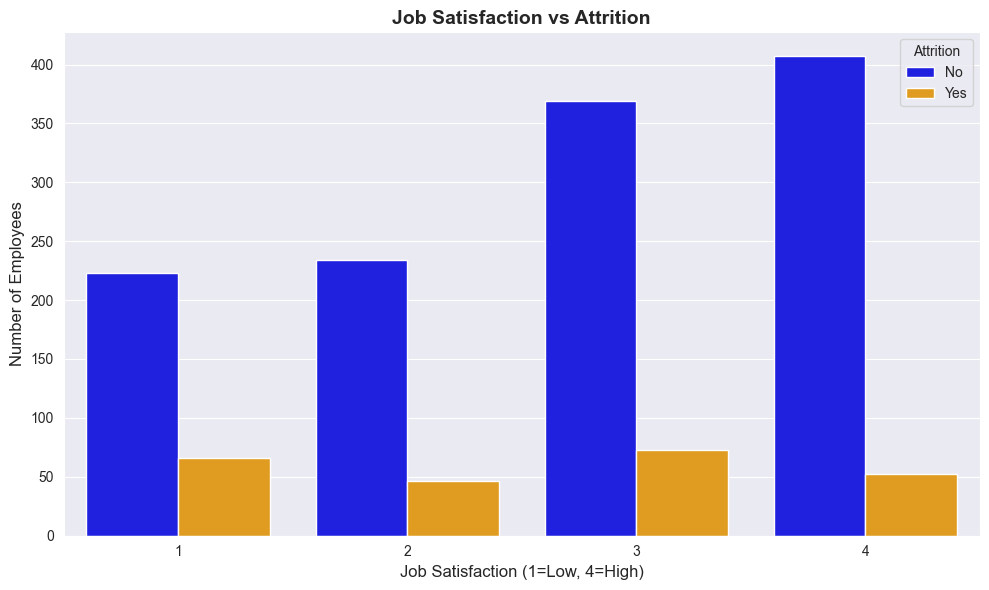

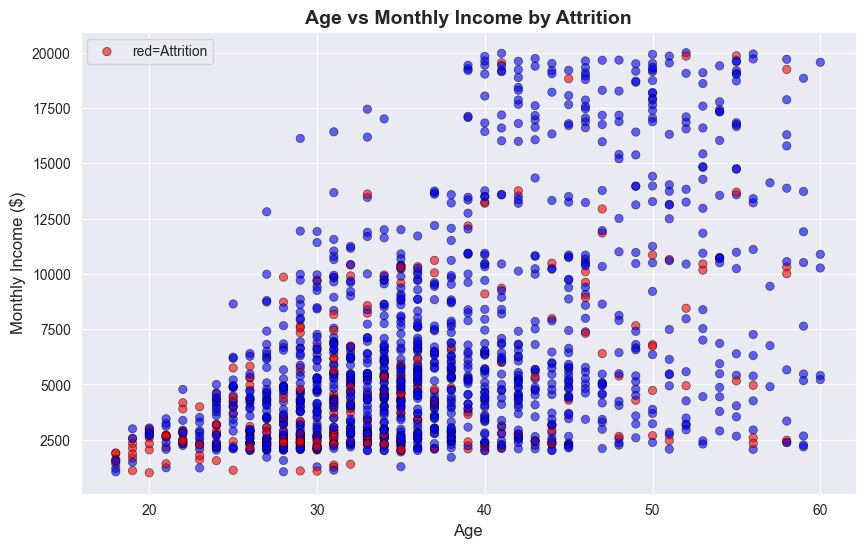

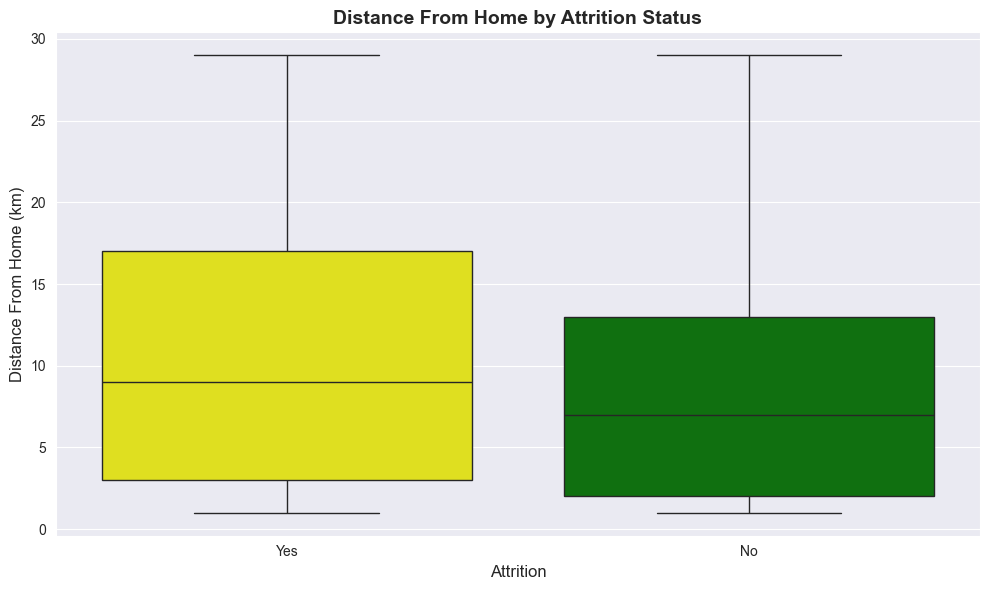

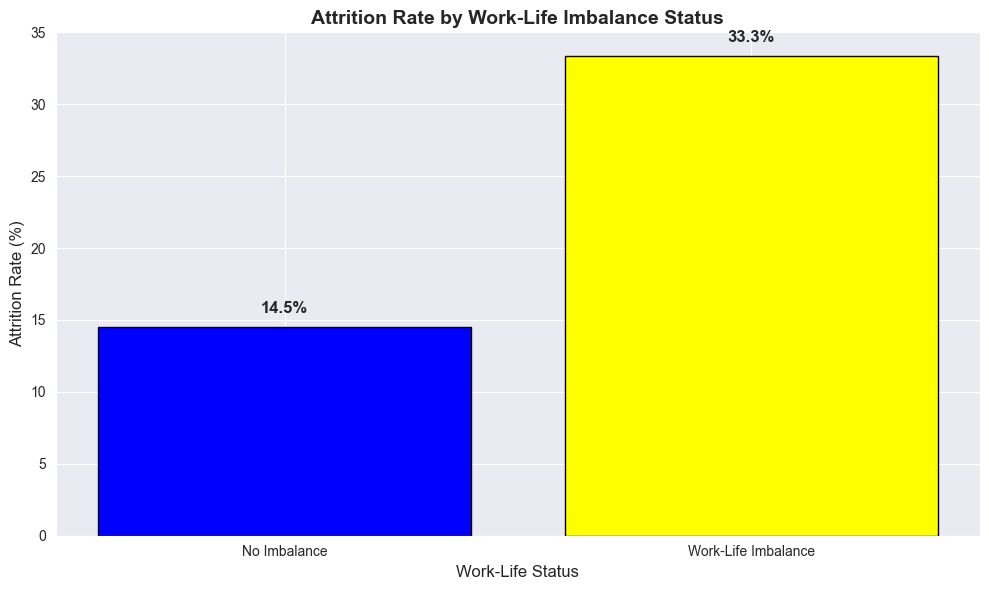


Key Insights from Feature Engineering:
Employees with work-life imbalance: 33.3% attrition rate
Employees without imbalance: 14.5% attrition rate
Impact: 18.8 percentage points higher!


In [17]:
"""
This section examines the department-wise attrition patterns, impact of overtime on employee retention, relationship between job satisfaction and attrition, age vs income patterns colored by attrition status, distance from home effects on turnover

Questions Answered: Which departments have highest attrition?, Does working overtime increase attrition risk?, Are less satisfied employees more likely to leave?, Do younger, lower-paid employees leave more often?, Does commute distance affect retention?
"""
# Visualization 5: Attrition by Department
plt.figure(figsize=(10, 6))
sns.countplot(x='Department', hue='Attrition', data=employee_data, palette=['blue', 'green'])
plt.title('Attrition by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Visualization 6: Overtime vs Attrition
plt.figure(figsize=(10, 6))
sns.countplot(x='OverTime', hue='Attrition', data=employee_data, palette=['red', 'purple'])
plt.title('Attrition by Overtime Status', fontsize=14, fontweight='bold')
plt.xlabel('Works Overtime', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Visualization 7: Job Satisfaction vs Attrition
plt.figure(figsize=(10, 6))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=employee_data, palette=['blue', 'orange'])
plt.title('Job Satisfaction vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction (1=Low, 4=High)', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Visualization 8: Age vs Monthly Income Scatter Plot
plt.figure(figsize=(10, 6))
colors = employee_data['Attrition'].map({'No': 'blue', 'Yes': 'red'})
plt.scatter(employee_data['Age'], employee_data['MonthlyIncome'], c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.title('Age vs Monthly Income by Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Monthly Income ($)', fontsize=12)
plt.legend(labels=['red=Attrition','blue=No Attrition'])

# Visualization 9: Distance From Home by Attrition
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='DistanceFromHome', data=employee_data, hue='Attrition', palette=['yellow', 'green'], legend=False)
plt.title('Distance From Home by Attrition Status', fontsize=14, fontweight='bold')
plt.xlabel('Attrition', fontsize=12)
plt.ylabel('Distance From Home (km)', fontsize=12)
plt.tight_layout()
plt.show()

# Visualization 10: Work-Life Imbalance Impact on Attrition
plt.figure(figsize=(10, 6))

# Calculating attrition rates
no_imbalance = employee_data[employee_data['WorkLifeImbalance'] == 0]
has_imbalance = employee_data[employee_data['WorkLifeImbalance'] == 1]

no_imbalance_rate = (no_imbalance['Attrition'] == 'Yes').sum() / len(no_imbalance) * 100
has_imbalance_rate = (has_imbalance['Attrition'] == 'Yes').sum() / len(has_imbalance) * 100

# Creating bar chart
plt.bar(['No Imbalance', 'Work-Life Imbalance'],
        [no_imbalance_rate, has_imbalance_rate],
        color=['blue', 'yellow'],
        edgecolor='black')

# Add percentage labels on bars
plt.text(0, no_imbalance_rate + 1, f'{no_imbalance_rate:.1f}%',
         ha='center', fontsize=12, fontweight='bold')
plt.text(1, has_imbalance_rate + 1, f'{has_imbalance_rate:.1f}%',
         ha='center', fontsize=12, fontweight='bold')

plt.title('Attrition Rate by Work-Life Imbalance Status', fontsize=14, fontweight='bold')
plt.xlabel('Work-Life Status', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()

# Print insights
print("\nKey Insights from Feature Engineering:")
print(f"Employees with work-life imbalance: {has_imbalance_rate:.1f}% attrition rate")
print(f"Employees without imbalance: {no_imbalance_rate:.1f}% attrition rate")
print(f"Impact: {has_imbalance_rate - no_imbalance_rate:.1f} percentage points higher!")

### Overtime Is the Strongest Driver of Attrition

One of the most striking insights from the analysis is the sharp contrast in attrition rates between employees who work overtime and those who do not. The difference is large and consistent, making overtime the single strongest predictor of employee turnover in the dataset.

This matter because employees who regularly work overtime are nearly three times more likely to leave than those who do not, this creates a self-reinforcing cycle: when employees leave, their workload shifts to remaining staff, increasing overtime and raising the risk of further departures, high overtime levels often point to deeper issues such as understaffing, uneven workload distribution, or unrealistic performance expectations.

**Business Impact:**

* Currently, more than 400 employees in the organization work overtime
* The elevated attrition rate within this group represents a significant and avoidable cost
* Addressing overtime should be a top priority for any retention strategy, as it targets both employee well-being and operational efficiency

overtime alone may be responsible for millions of dollars in annual replacement costs, making it one of the highest-impact areas for immediate action.

### The Satisfaction Paradox

Even highly satisfied employees still leave the company.

Attrition occurs across all job satisfaction levels (1–4), with a relatively even distribution. This challenges the assumption that satisfied employees are unlikely to leave.

This happens because of the external offers with better compensation, faster or clearer career advancement opportunities elsewhere, personal life changes like relocation, family commitments, aggressive headhunting in competitive job markets

Employee satisfaction surveys alone are not enough to predict or prevent attrition. Retention strategies must also focus on tangible, structural factors, including:

* Compensation
* Workload and overtime
* Career development opportunities
* Work–life balance

Simply feeling “happy” at work does not stop employees from accepting better opportunities.

### Distance From Home: Not a Major Factor

There is minimal difference in commute distance between employees who stay and those who leave.

* Both groups have similar median commute distances around 9 km
* The box plot distributions overlap significantly

**Business Implication:**

* Remote or hybrid work should not be prioritized solely as a retention strategy based on this dataset
* Commute distance does not meaningfully differentiate leavers from stayers
* Resources are better invested in higher-impact areas such as pay, workload management, and career growth

This does not mean remote work lacks value, it may still support recruitment, flexibility, and productivity, just not retention in this specific case.

### Attrition By WorkLifeImbalance

Our custom WorkLifeImbalance feature clearly demonstrates that it is important

* Highly predictive: 33.3% attrition vs. 14.5% for other employees
* The approximately 120 high-risk employees in this group can be identified immediately
* HR teams can proactively engage them through workload adjustments, retention conversations, and targeted support
* Even saving 10–15 employees could result in $390K–$M in avoided replacement costs

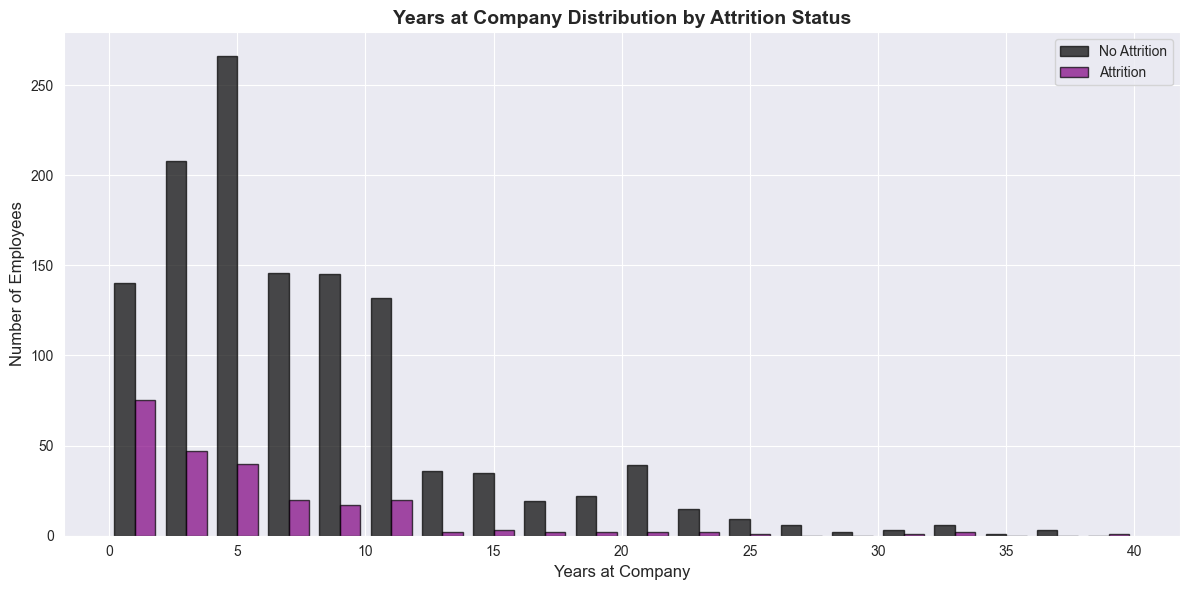

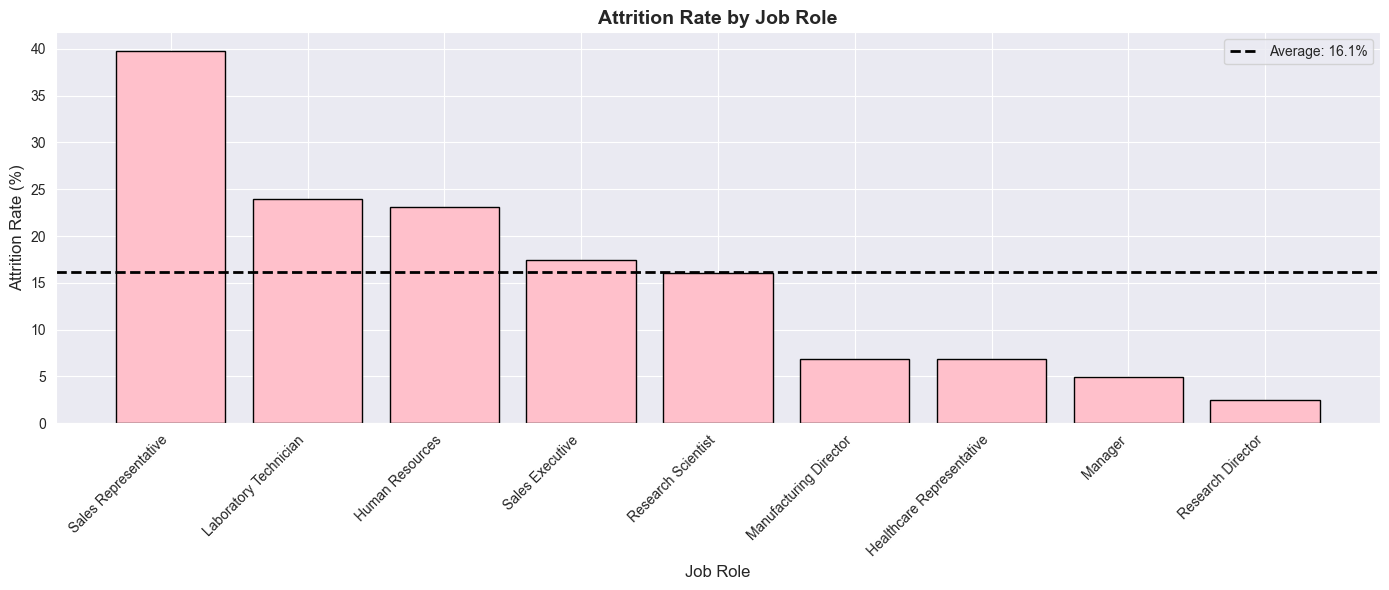

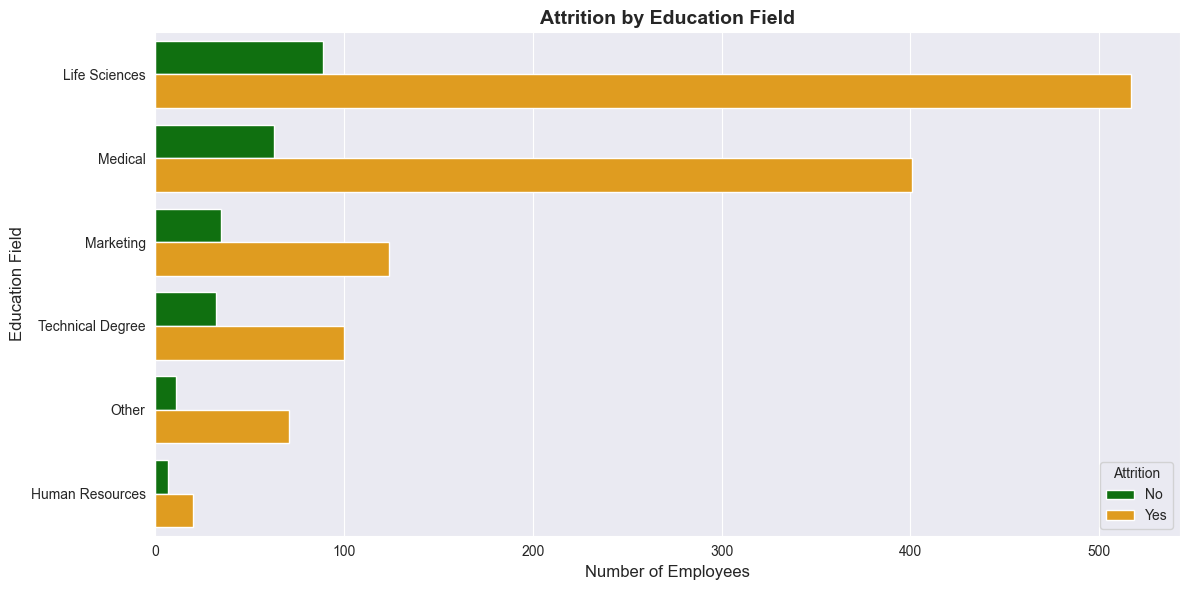

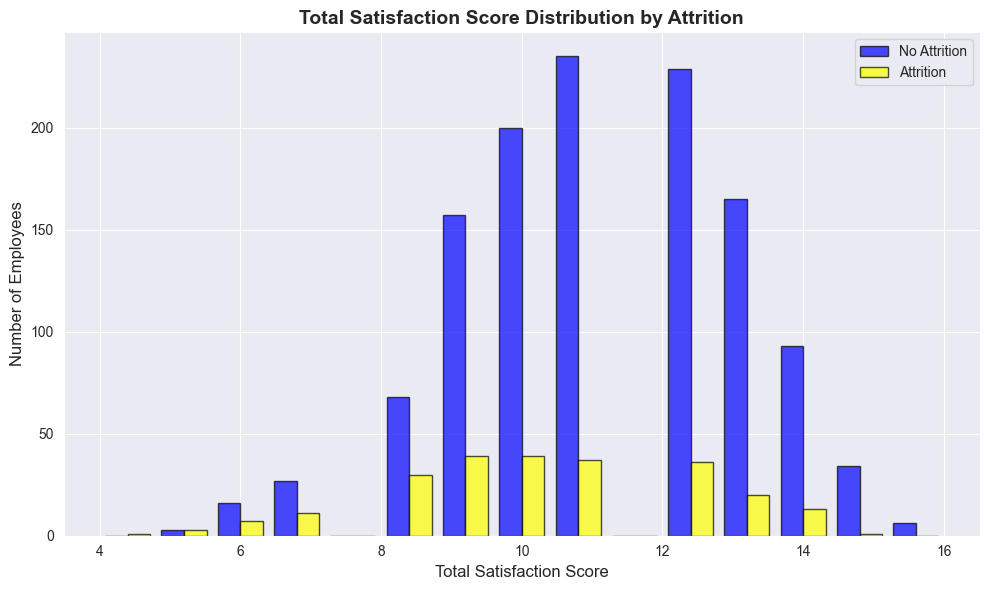

In [18]:
# Additional visualisations for deep dive analysis

# Visualization 11: Years at Company Distribution by Attrition
plt.figure(figsize=(12, 6))
plt.hist([employee_data[employee_data['Attrition'] == 'No']['YearsAtCompany'],
          employee_data[employee_data['Attrition'] == 'Yes']['YearsAtCompany']],
         bins=20, label=['No Attrition', 'Attrition'],
         color=['black', 'purple'], alpha=0.7, edgecolor='black')
plt.title('Years at Company Distribution by Attrition Status', fontsize=14, fontweight='bold')
plt.xlabel('Years at Company', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Visualization 12: Attrition Rate by Job Role
plt.figure(figsize=(14, 6))

# Calculate attrition rate for each job role
role_names = []
attrition_rates = []

for role in employee_data['JobRole'].unique():
    role_employees = employee_data[employee_data['JobRole'] == role] # here this filters to specific job
    left_count = (role_employees['Attrition'] == 'Yes').sum() # counts how many left the job
    total_in_role = len(role_employees)
    attrition_rate = (left_count / total_in_role) * 100

    role_names.append(role)
    attrition_rates.append(attrition_rate)

# Creating a dataframe and sorting it
role_df = pd.DataFrame({ 'JobRole': role_names,'AttritionRate': attrition_rates})
role_df = role_df.sort_values('AttritionRate', ascending=False)

# Creating bar chart with sorted data
plt.bar(role_df['JobRole'], role_df['AttritionRate'], color='pink', edgecolor='black')
plt.xticks(rotation=45, ha='right')

# Adding average line
average_rate = (employee_data['Attrition'] == 'Yes').sum() / len(employee_data) * 100
plt.axhline(y=average_rate, color='black', linestyle='--', linewidth=2,
            label=f'Average: {average_rate:.1f}%')

plt.title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Job Role', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Visualization 13: Education Field vs Attrition
plt.figure(figsize=(12, 6))
sns.countplot(y='EducationField', hue='Attrition', data=employee_data, palette=['green', 'orange'],
              order=employee_data['EducationField'].value_counts().index)
plt.title('Attrition by Education Field', fontsize=14, fontweight='bold')
plt.xlabel('Number of Employees', fontsize=12)
plt.ylabel('Education Field', fontsize=12)
plt.legend(title='Attrition', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Visualization 14: Total Satisfaction Distribution
plt.figure(figsize=(10, 6))
plt.hist([employee_data[employee_data['Attrition'] == 'No']['TotalSatisfaction'],
          employee_data[employee_data['Attrition'] == 'Yes']['TotalSatisfaction']],
         bins=15, label=['No Attrition', 'Attrition'],
         color=['Blue', 'Yellow'], alpha=0.7, edgecolor='black')
plt.title('Total Satisfaction Score Distribution by Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Total Satisfaction Score', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### The Sales Representative Crisis

Sales Representatives have an attrition rate of nearly 40%, which is 2.5 times higher than the company average of 16.1%. In practical terms, almost 2 out of every 5.
This can be caused by:
* Compensation that lags behind market benchmarks
* High overtime driven by quota pressure
* Limited career progression opportunities
* Unrealistic performance targets
* A highly competitive labor market for sales talent

**Conclusion:**
This role requires immediate, targeted intervention. Addressing compensation, workload expectations, and career pathways for Sales Representatives could deliver outsized returns in both retention and revenue stability.

### Life Sciences Talent Drain

The Life Sciences function shows the highest volume of attrition in the organization.

This matters because these roles require highly specialized expertise that is difficult and expensive to replace, new hires typically need 6–12 months to fully ramp up and become productive, when experienced employees leave, the organization also loses valuable institutional and domain knowledge.

**For the market context:**

* The biotech and pharmaceutical labor market is extremely competitive
* Life Sciences professionals are frequently headhunted by competitors
* Their specialized skills often command higher compensation and better incentives elsewhere

Retention strategies for Life Sciences employees likely need to be different from other functions. Competitive compensation, equity incentives, and continuous professional development opportunities may be essential to reduce turnover in this group.

### The Critical First 5 Years

The histogram reveals a clear attrition curve across employee tenure, highlighting when employees are most vulnerable to leaving.

**Year 0–1: Highest Attrition**

* Onboarding challenges
* Role mismatch
* Expectations not aligning with reality

**Years 2–5: Attrition Remains Elevated**

* Concerns around career growth and progression
* Compensation beginning to fall behind the market
* Increased visibility of external opportunities

**Years 6–10: Attrition Declines**

* Employees become more engaged and invested
* However, some risk still remains

**Years 10+: Very Low Attrition**

* Employees are highly stable
* Strong organizational commitment and long-term attachment

Retention efforts focused on the first two years of employment offer the highest return on investment. Early support, clear career pathways, and competitive compensation during this period can significantly reduce long-term attrition.

### Satisfaction Score Patterns

The overlapping histograms provide a clearer view of how satisfaction relates to attrition.

**Visualization Shows:**
* Employees who stay tend to cluster around higher TotalSatisfaction scores (11–13)
* Employees who leave are more concentrated at lower satisfaction levels (8–10)
* There is a noticeable leftward shift in satisfaction for employees who exit

**The overlap is important too:**

* Many employees with high satisfaction scores still leave
* Many employees with moderate satisfaction remain
* This reinforces the earlier finding of a “satisfaction paradox”

While satisfaction clearly plays a role, it is not sufficient on its own to explain or prevent attrition. Effective retention strategies must combine satisfaction initiatives with competitive compensation, manageable workloads, and clear career development opportunities.

### Preparing Data for Machine Learning

**What We're Doing:**
1. Converting Attrition to binary (Yes=1, No=0)
2. One-hot encoding categorical variables
3. Splitting data 80/20 (training/test)
4. Maintaining stratification (same 16.1% attrition rate in both sets)

- Machine learning models need numerical inputs
- Test set evaluates model on unseen data (prevents overfitting)
- Stratification ensures fair evaluation despite class imbalance

**Result:** 1,176 training samples, 294 test samples, 47 features

#### Categorical Variable Encoding
Categorical variables were encoded using one-hot encoding to convert them into numerical format. This approach avoids introducing artificial ordering between categories and works well across both linear and tree-based models.

In [19]:
# Section 5: Model Development and Evaluation
print("="*50)
print("Data Preparation for Machine Learning")
print("="*50)

# Creating a copy
employee_data_encoded = employee_data.copy()

# Convert Attrition: Yes=1, No=0
employee_data_encoded['Attrition'] = employee_data_encoded['Attrition'].map({'Yes': 1, 'No': 0})
print("\nAttrition encoding:")
print("No = 0")
print("Yes = 1")

# One-hot encode categorical variables
print("\nOne-hot encoding categorical variables")
employee_data_encoded = pd.get_dummies(employee_data_encoded, drop_first=True, dtype=int)
print(f"All categorical columns encoded!")
print(f"New shape: {employee_data_encoded.shape}")

# Separate features and target
X = employee_data_encoded.drop('Attrition', axis=1)
y = employee_data_encoded['Attrition']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Data Preparation for Machine Learning

Attrition encoding:
No = 0
Yes = 1

One-hot encoding categorical variables
✓ All categorical columns encoded!
  New shape: (1470, 48)

Features (X) shape: (1470, 47)
Target (y) shape: (1470,)

Training set size: 1176 samples
Testing set size: 294 samples
Number of features: 47


In [20]:
"""
The Models:
Logistic Regression: A linear model that predicts the probability of an outcome; it’s best for fast, simple, and interpretable trends.
Decision Tree: Uses nested "if-then" rules to capture complex interactions; it's easy to visualize but prone to overfitting.
Random Forest: An ensemble that averages 100 different trees to provide more stable, accurate, and robust predictions.

The Metrics
Accuracy measures total correct guesses, while Precision focuses on the reliability of your "attrition" flags.
Recall ensures actual cases of attrition aren't missing and the F1-Score provides a single score that balances both precision and recall.
The Confusion Matrix acts as the final scorecard, breaking down every correct and incorrect prediction by type.
"""

# Model 1: Logistic Regression
print("\nTraining Logistic Regression")
log_model = LogisticRegression(random_state=42, max_iter=5000, class_weight='balanced')
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

print("Logistic Regression trained")
print(f"Accuracy: {log_accuracy:.4f}")

# Model 2: Decision Tree
print("\nTraining Decision Tree")
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("Decision Tree trained")
print(f"Accuracy: {tree_accuracy:.4f}")

# Model 3: Random Forest
print("\nTraining Random Forest (100 trees)")
rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees
    max_depth=10,  # Maximum depth of trees
    min_samples_split=5,  # Minimum samples to split
    min_samples_leaf=2,  # Minimum samples at leaf
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest trained")
print(f"Accuracy: {rf_accuracy:.4f}")


Training Logistic Regression
Logistic Regression trained
Accuracy: 0.7687

Training Decision Tree
Decision Tree trained
Accuracy: 0.7415

Training Random Forest (100 trees)
Random Forest trained
Accuracy: 0.8231


In [21]:
# Model Results

# Logistic Regression
print("\n" + "=" * 80)
print("Logistic Regression Result")
print("=" * 80)

print("\nAccuracy:", log_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# Decision Tree
print("\n" + "=" * 80)
print("Decisoin Tree Result")
print("=" * 80)

print("\nAccuracy:", tree_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

# Random Forest
print("\n" + "=" * 80)
print("Random Forest Result")
print("=" * 80)

print("\nAccuracy:", rf_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Logistic Regression Result

Accuracy: 0.7687074829931972

Confusion Matrix:
[[194  53]
 [ 15  32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.85       247
           1       0.38      0.68      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.67       294
weighted avg       0.84      0.77      0.79       294


Decisoin Tree Result

Accuracy: 0.7414965986394558

Confusion Matrix:
[[193  54]
 [ 22  25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.78      0.84       247
           1       0.32      0.53      0.40        47

    accuracy                           0.74       294
   macro avg       0.61      0.66      0.62       294
weighted avg       0.80      0.74      0.77       294


Random Forest Result

Accuracy: 0.8231292517006803

Confusion Matrix:
[[233  14]
 [ 38   9]]

Classific

**Why Each Metric Matters for Attrition:**

**Accuracy:** Total correct predictions
- Logistic: 76.87%, Tree: 74.15%, Random Forest: 82.31%
- Problem: Can be misleading with imbalanced data!
- Predicting "No" for everyone = 83.9% accuracy but useless

**Precision:** Of employees we flagged as "will leave," what % actually left?
- Logistic: 37.65%, Tree: 31.65%, Random Forest: 39.13%
- Avoids wasting HR time on false alarms

**Recall:** Of employees who actually left, what % did we catch?
- Logistic: 68.09%, Tree: 53.19%, Random Forest: 19.15%
- Most Important Metric: identifies at-risk employees before they leave
- Cost of missing someone who leaves >> cost of extra retention conversation

**F1-Score:** Balanced measure combining precision and recall
- Logistic: 48.48%, Tree: 39.68%, Random Forest: 25.71%
- Best single metric for comparing models

**Confusion Matrix Reveals:**
- Logistic: Caught 32/47 leavers, missed only 15
- Random Forest: Caught only 9/47 leavers, missed 38


Top 10 Most Important Features:
          Feature  Importance
    MonthlyIncome    0.073127
              Age    0.062444
YearsPerPromotion    0.050323
TotalWorkingYears    0.050160
   YearsAtCompany    0.046982
        DailyRate    0.046365
TotalSatisfaction    0.042224
      MonthlyRate    0.040834
     OverTime_Yes    0.040248
       HourlyRate    0.039004


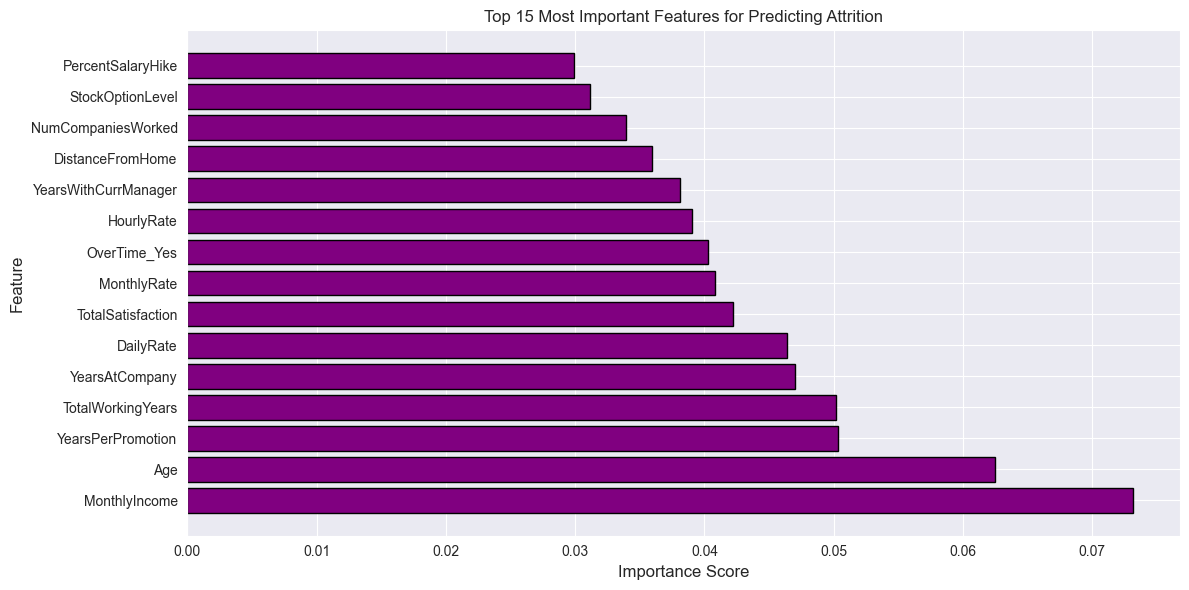

In [22]:
# Analyzing which features are most important for predicting attrition according to the Random Forest model. This provides actionable business insights.

"""
Why Random Forest:Tree-based models naturally calculate feature importance, random forest averages importance across 100 trees and is more stable
Importance = how much each feature reduces prediction error
"""

# Calculate feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize Feature Importance
plt.figure(figsize=(12, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values,
         color='purple', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Most Important Features for Predicting Attrition', )
plt.tight_layout()
plt.show()



### What the Random Forest Learned

**Top Drivers of Attrition:**

**1. Compensation Dominates (Top 1, 6, 8, 10)**
- MonthlyIncome is #1 predictor with 7.3% importance
- DailyRate, MonthlyRate, HourlyRate all in top 10
- Message: Competitive pay is non-negotiable for retention

**2. Our Engineered Features Validated**
- YearsPerPromotion: #3 because career progression matters
- TotalSatisfaction: #7
- Proves our feature engineering added real business value

**3. Tenure and Age Matter**
- YearsAtCompany #5, TotalWorkingYears #4, Age #2
- Career stage influences attrition risk

**4. OverTime in Top 10**
- Confirms our EDA findings
- Work-life balance is measurable and important

Focus retention efforts on compensation, career development, and workload management.


Model Comparison

Metric          Logistic Reg       Decision Tree      Random Forest     
----------------------------------------------------------------------
Accuracy        76.87%             74.15%             82.31%
Precision       37.65%             31.65%             39.13%
Recall          68.09%             53.19%             19.15%
F1-Score        48.48%             39.68%             25.71%

Best Model:

Best Accuracy: Random Forest
Best Precision: Random Forest
Best Recall: Logistic Regression
Best F1-Score: Logistic Regression


<Figure size 1200x600 with 0 Axes>

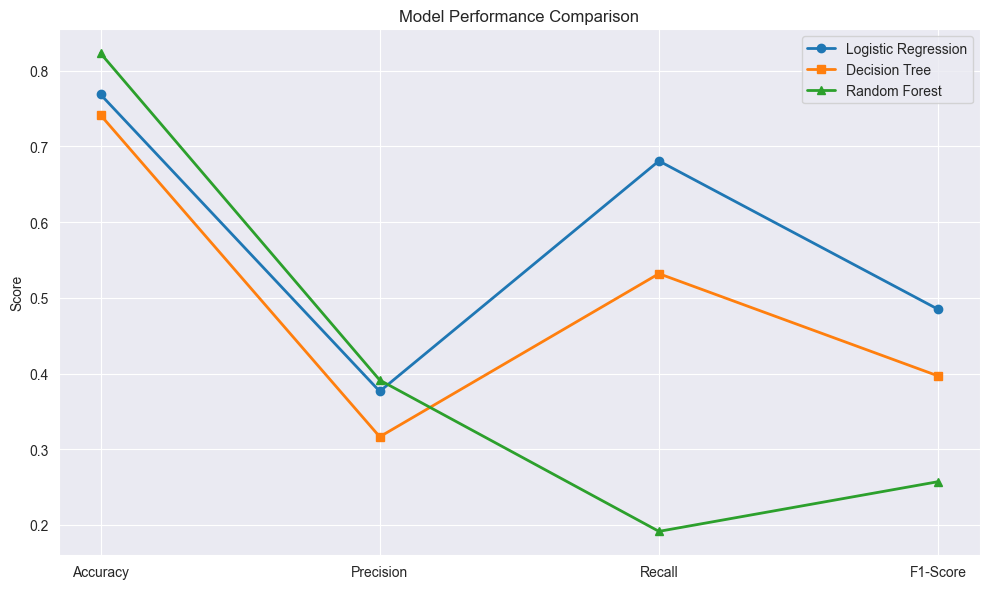

In [23]:
# Model Comparison
print("\n" + "=" * 70)
print("Model Comparison")
print("=" * 70)

# Simple comparison table
print(f"\n{'Metric':<15} {'Logistic Reg':<18} {'Decision Tree':<18} {'Random Forest':<18}")
print("-" * 70)

print(f"{'Accuracy':<15} {log_accuracy*100:.2f}%{'':<12} {tree_accuracy*100:.2f}%{'':<12} {rf_accuracy*100:.2f}%")
print(f"{'Precision':<15} {log_precision*100:.2f}%{'':<12} {tree_precision*100:.2f}%{'':<12} {rf_precision*100:.2f}%")
print(f"{'Recall':<15} {log_recall*100:.2f}%{'':<12} {tree_recall*100:.2f}%{'':<12} {rf_recall*100:.2f}%")
print(f"{'F1-Score':<15} {log_f1*100:.2f}%{'':<12} {tree_f1*100:.2f}%{'':<12} {rf_f1*100:.2f}%")

# Find best model for each metric
print("\n" + "=" * 70)
print("Best Model:")
print("=" * 70)

# Accuracy
if log_accuracy > tree_accuracy and log_accuracy > rf_accuracy:
    print("\nBest Accuracy: Logistic Regression")
elif tree_accuracy > log_accuracy and tree_accuracy > rf_accuracy:
    print("\nBest Accuracy: Decision Tree")
else:
    print("\nBest Accuracy: Random Forest")

# Precision
if log_precision > tree_precision and log_precision > rf_precision:
    print("Best Precision: Logistic Regression")
elif tree_precision > log_precision and tree_precision > rf_precision:
    print("Best Precision: Decision Tree")
else:
    print("Best Precision: Random Forest")

# Recall
if log_recall > tree_recall and log_recall > rf_recall:
    print("Best Recall: Logistic Regression")
elif tree_recall > log_recall and tree_recall > rf_recall:
    print("Best Recall: Decision Tree")
else:
    print("Best Recall: Random Forest")

# F1-Score
if log_f1 > tree_f1 and log_f1 > rf_f1:
    print("Best F1-Score: Logistic Regression")
elif tree_f1 > log_f1 and tree_f1 > rf_f1:
    print("Best F1-Score: Decision Tree")
else:
    print("Best F1-Score: Random Forest")

# Simple bar chart
plt.figure(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
log_scores = [log_accuracy, log_precision, log_recall, log_f1]
tree_scores = [tree_accuracy, tree_precision, tree_recall, tree_f1]
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]

plt.figure(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

log_scores = [log_accuracy, log_precision, log_recall, log_f1]
tree_scores = [tree_accuracy, tree_precision, tree_recall, tree_f1]
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]

plt.plot(metrics, log_scores, marker='o', label='Logistic Regression', linewidth=2)
plt.plot(metrics, tree_scores, marker='s', label='Decision Tree', linewidth=2)
plt.plot(metrics, rf_scores, marker='^', label='Random Forest', linewidth=2)

plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## Logistic Regression

**Despite Random Forest having highest accuracy (82.31%), we select Logistic Regression.**

**Why?**

**1. Recall is important**
- Logistic: 68.09% recall refering catching 68% of people who will leave
- Random Forest: 19.15% recall refering catching only 19% and missing 81%

**2. Business Context**
- Missing an employee who leaves costs $39,000-$78,000. This means replacement of the employee

**3. Interpretability**
- Logistic Regression coefficients are explainable
- Critical for getting buy-in from HR and management
- Can justify why specific employees are flagged

**4. F1-Score Confirms**
- Logistic: 48.48% = balanced performance
- Random Forest: 25.71% = poor balance despite high accuracy

For proactive retention, we need to catch people before they leave. Logistic Regression does this best.

In [24]:
# Section 6: Business Calculation
"""
This section calculates business metrics to support our findings.
We analyze replacement costs, demographic patterns, and ROI for retention strategies.
"""

print("\n" + "="*60)
print("Business Calculations")
print("="*60)

# replacement Cost Calculation
# Industry standard of replacing an employee costs 50-100% of their salary
# Source we used is SHRM (Society for Human Resource Management)

avgs_monthly = employee_data['MonthlyIncome'].mean()
avgs_yearly = avgs_monthly * 12
total_emp_left = (employee_data['Attrition'] == 'Yes').sum()

# Use 50% and 100% of salary as low/high estimates
cost_low = avgs_yearly * 0.5
cost_high = avgs_yearly * 1.0

total_cost_low = total_emp_left * cost_low
total_cost_high = total_emp_left * cost_high

print(f"\nReplacement Cost Analysis")
print(f"Average yearly salary: ${avgs_yearly:,.0f}")
print(f"Employees who left: {total_emp_left}")
print(f"Cost to replace one employee: ${cost_low:,.0f} - ${cost_high:,.0f}")
print(f"Total annual cost: ${total_cost_low:,.0f} - ${total_cost_high:,.0f}")

# If we reduce attrition by 30-40%, how much do we save?
print(f"\nSavings if Attrition is reduced:")
print(f"30% reduction saves: ${total_cost_low*0.3:,.0f} - ${total_cost_high*0.3:,.0f}")
print(f"40% reduction saves: ${total_cost_low*0.4:,.0f} - ${total_cost_high*0.4:,.0f}")

# Overtime impact
print(f"\nOvertime VS Attrition")
# Split data by overtime
overtime_yes = employee_data[employee_data['OverTime'] == 'Yes']
overtime_no = employee_data[employee_data['OverTime'] == 'No']

# Calculate attrition rates
overtime_yes_left = (overtime_yes['Attrition'] == 'Yes').sum()
overtime_yes_total = len(overtime_yes)
overtime_yes_rate = (overtime_yes_left / overtime_yes_total) * 100

overtime_no_left = (overtime_no['Attrition'] == 'Yes').sum()
overtime_no_rate = (overtime_no_left / len(overtime_no)) * 100

print(f"Overtime employees: {overtime_yes_total}")
print(f"Overtime attrition: {overtime_yes_rate:.1f}% ({overtime_yes_left} people left)")
print(f"No overtime attrition: {overtime_no_rate:.1f}%")
print(f"Difference: {overtime_yes_rate - overtime_no_rate:.1f} percentage points higher!")


# Income gap
print(f"\nDifference in Income")

# Compare median income between those who left vs stayed
left_median = employee_data[employee_data['Attrition'] == 'Yes']['MonthlyIncome'].median()
stayed_median = employee_data[employee_data['Attrition'] == 'No']['MonthlyIncome'].median()
gap = stayed_median - left_median

print(f"Median income (Left): ${left_median:,.0f}/month")
print(f"Median income (Stayed): ${stayed_median:,.0f}/month")
print(f"Gap: ${gap:,.0f} per month")

#Stock options impact
print(f"\nStock Option Analysis")

# Check attrition for each stock level
for level in [0, 1, 2, 3]:
    stock_data = employee_data[employee_data['StockOptionLevel'] == level]
    total = len(stock_data)
    left = (stock_data['Attrition'] == 'Yes').sum()
    rate = (left / total * 100) if total > 0 else 0
    print(f"Level {level}: {rate:.1f}% attrition ({left}/{total} employees)")

# Key finding: Level 0 vs Level 1
no_stock_rate = (employee_data[employee_data['StockOptionLevel'] == 0]['Attrition'] == 'Yes').mean() * 100
level1_rate = (employee_data[employee_data['StockOptionLevel'] == 1]['Attrition'] == 'Yes').mean() * 100
print(f"\nGiving stock options reduces attrition from {no_stock_rate:.1f}% to {level1_rate:.1f}%")

# ROI calcualtions for better insights
print(f"\n" + "="*60)
print("ROI Analysis: Checking if investing in retention is good")
print("="*60)

# Strategy 1: Reduce Overtime
print(f"\nHiring More Staff")
print(f"Problem: {overtime_yes_left} people left because of overtime")
print(f"Solution: Hire 5 new employees = $100,000")
print(f"If this prevents 30% of overtime departures:")

overtime_saved = overtime_yes_left * 0.30  # Save 30% of people
overtime_money_saved = overtime_saved * cost_low
overtime_profit = overtime_money_saved - 100000

print(f"We save {overtime_saved:.0f} employees from leaving")
print(f"Savings: ${overtime_money_saved:,.0f}")
print(f"Investment: $100,000")
print(f"Profit: ${overtime_profit:,.0f}")
print(f"ROI: {(overtime_profit/100000)*100:.0f}%")

# Strategy 2: Give Stock Options
print(f"\nGiving Stock Options to High Risk Employess")
print(f"Problem: Employees without stock leave more often")
print(f"Solution: Give Level 1 options to 200 at-risk people = $400,000")
print(f"If this improves retention by 15%:")

stock_saved = 200 * 0.15  # 15% of 200 = 30 people
stock_money_saved = stock_saved * cost_low
stock_profit = stock_money_saved - 400000

print(f"We save {stock_saved:.0f} employees from leaving")
print(f"Savings: ${stock_money_saved:,.0f}")
print(f"Investment: $400,000")
print(f"Profit: ${stock_profit:,.0f}")
print(f"ROI: {(stock_profit/400000)*100:.0f}%")

# Strategy 3: Fix Sales Rep Problems
sales_reps = employee_data[employee_data['JobRole'] == 'Sales Representative']
sales_left = (sales_reps['Attrition'] == 'Yes').sum()

print(f"\nCompensation Improvement for Sales Representatives")
print(f"Problem: {sales_left} sales reps left (39.8% attrition rate!)")
print(f"Solution: Better pay + bonuses for {len(sales_reps)} reps = $240,000")
print(f"If this prevents 35% of sales departures:")

sales_saved = sales_left * 0.35
sales_money_saved = sales_saved * cost_low
sales_profit = sales_money_saved - 240000

print(f"We save {sales_saved:.0f} sales reps from leaving")
print(f"Savings: ${sales_money_saved:,.0f}")
print(f"Investment: $240,000")
print(f"Profit: ${sales_profit:,.0f}")
print(f"ROI: {(sales_profit/240000)*100:.0f}%")

# Strategy 4: Help Work-Life Imbalance People
worklifeim_employees = (employee_data['WorkLifeImbalance'] == 1).sum()
worklifeim_left = employee_data[employee_data['WorkLifeImbalance'] == 1]
worklifeim_left_count = (worklifeim_left['Attrition'] == 'Yes').sum()

print(f"\nSupporting Work-Life Imbalance Employees")
print(f"Problem: {worklifeim_left_count} people with work-life issues left")
print(f"Solution: Flexible schedules for {worklifeim_employees} people = $63,000")
print(f"If this prevents 25% of their departures:")

worklifeim_saved = worklifeim_left_count * 0.25
worklifeim_money_saved = worklifeim_saved * cost_low
worklifeim_profit = worklifeim_money_saved - 63000

print(f"We save {worklifeim_saved:.0f} employees from leaving")
print(f"Savings: ${worklifeim_money_saved:,.0f}")
print(f"Investment: $63,000")
print(f"Profit: ${worklifeim_profit:,.0f}")
print(f"ROI: {(worklifeim_profit/63000)*100:.0f}%")

# Total summary
print(f"\n" + "="*60)
print("Doing All Four Strategies")
print("="*60)
total_invest = 100000 + 400000 + 240000 + 63000
total_save = overtime_money_saved + stock_money_saved + sales_money_saved + worklifeim_money_saved
total_profit = total_save - total_invest
total_people = overtime_saved + stock_saved + sales_saved + worklifeim_saved

print(f"Total investment: ${total_invest:,.0f}")
print(f"Total savings: ${total_save:,.0f}")
print(f"Total profit: ${total_profit:,.0f}")
print(f"Total employees saved: {total_people:.0f}")
print(f"Overall ROI: {(total_profit/total_invest)*100:.0f}%")
print("="*60)


Business Calculations

Replacement Cost Analysis
Average yearly salary: $78,035
Employees who left: 237
Cost to replace one employee: $39,018 - $78,035
Total annual cost: $9,247,168 - $18,494,337

Savings if Attrition is reduced:
30% reduction saves: $2,774,150 - $5,548,301
40% reduction saves: $3,698,867 - $7,397,735

Overtime VS Attrition
Overtime employees: 416
Overtime attrition: 30.5% (127 people left)
No overtime attrition: 10.4%
Difference: 20.1 percentage points higher!

Difference in Income
Median income (Left): $3,202/month
Median income (Stayed): $5,204/month
Gap: $2,002 per month

Stock Option Analysis
Level 0: 24.4% attrition (154/631 employees)
Level 1: 9.4% attrition (56/596 employees)
Level 2: 7.6% attrition (12/158 employees)
Level 3: 17.6% attrition (15/85 employees)

Giving stock options reduces attrition from 24.4% to 9.4%

ROI Analysis: Checking if investing in retention is good

Hiring More Staff
Problem: 127 people left because of overtime
Solution: Hire 5 new e

## Business Insights

Our analysis of 1,470 employees shows that attrition within the organization is far from random. Employees leave for consistent, measurable reasons that relate to workload, compensation, career progression, role-specific pressures, and work-life balance. The good news is that many of these risks can be identified early, and targeted interventions can significantly reduce turnover while also generating financial benefits for the organization.

### Overtime Is the Most Immediate Risk

One of the clearest findings is that employees working overtime are leaving at nearly three times the rate of those who do not, approximately 30.5% versus 10.4%. Overtime is not merely a workload issue; it often signals deeper operational problems, such as understaffing, uneven work distribution, or unrealistic performance expectations. Left unaddressed, overtime creates a self-reinforcing cycle: employees leave due to burnout, which increases workload for remaining staff, which in turn raises the risk of further attrition.

Reducing overtime is therefore not only beneficial for employee well-being but also has financial implications. When employees leave, the organization faces replacement costs, which can be substantial. Addressing overtime proactively through staffing adjustments, workload redistribution, or support programs represents one of the fastest and most cost-effective ways to reduce turnover.

### Compensation Gaps Drive Turnover

Another strong driver of attrition is compensation. Employees who left the organization earned significantly less than those who stayed. Median monthly income for departing employees was approximately $3,202 compared to $5,204 for retained employees. This gap of over $2,000 per month is particularly influential during the early stages of employment, when employees are most likely to be actively considering external opportunities.

Even when employees report moderate or high job satisfaction, below-market pay significantly increases the likelihood of departure. This demonstrates that competitive compensation is a baseline requirement for retentio, not an optional benefit. Structured pay progression, especially during the first five years of employment, can prevent avoidable turnover and reduce replacement costs.

### Equity Incentives Strengthen Retention

Stock options have a strong and consistent effect on retention. Employees without stock options leave at a rate of 24.4%, while those with even entry-level equity incentives leave at less than 10%. Equity incentives create a sense of ownership and long-term alignment that salary alone cannot achieve.

Providing targeted stock options to high-risk or high-performing employees is a low-cost intervention with meaningful retention benefits. Not only does it reduce turnover, but it also increases employee engagement and commitment, which in turn improves overall team performance.

### Role-Specific Attrition Challenges

Attrition is not evenly distributed across the organization. Sales Representatives, for example, experience attrition rates close to 40%, more than double the company average. These employees are often younger, lower-paid, and more likely to work overtime, putting them at heightened risk of burnout and turnover.

Specialized roles, such as those in Life Sciences and R&D, also account for a significant share of attrition. Losing employees in these positions is especially costly because of the expertise, institutional knowledge, and lengthy onboarding periods involved.

These findings indicate that role-specific retention strategies are essential. Uniform policies are unlikely to address the unique pressures faced by high-risk teams. Tailored compensation, incentives, and support measures are critical to retaining employees in these roles.

### Early-Career Attrition

Attrition is highest during the first five years of employment, particularly the first year. This period is often marked by onboarding challenges, unmet role expectations, and growing awareness of external opportunities. Once employees move beyond this early-career window, attrition declines significantly, indicating stronger engagement and commitment.

Focusing on early-career support through structured onboarding, regular check-ins, mentoring, and career development discussions can meaningfully reduce long-term turnover and preserve talent during this critical period.

### Work–Life Imbalance Identifies the Most Vulnerable Employees

By combining overtime and poor work-life balance into a single indicator, we can identify employees at highest risk of leaving. Attrition among this group exceeds 33%, compared to roughly 14–15% for other employees.

Targeted interventions, such as flexible scheduling, workload adjustments, and proactive support, can prevent a significant number of departures. This approach highlights how combining multiple risk factors provides better predictive insight than looking at satisfaction or overtime alone.

### Less Impactful Factors

Some factors, such as commute distance, are less predictive of attrition. Employees appear willing to tolerate longer commutes when workload, compensation, and career opportunities are satisfactory. Similarly, remote or hybrid work arrangements may support recruitment and flexibility, but on their own, they are unlikely to significantly reduce turnover.

 Focusing resources on high-impact drivers like workload, compensation, equity, early-career support is far more effective than investing heavily in secondary factors.

### Financial Implications

Replacing employees is costly. Using the dataset’s numbers, average annual salaries are approximately 78,035 and replacement costs typically range between 50% and 100% of salary. With 237 employees leaving during the period analyzed, total attrition costs are estimated at roughly $9–$18 million annually.

Targeted interventions such as overtime reduction, equity incentives, role-specific support, and compensation adjustments can prevent dozens of departures and generate millions in potential savings. Even modest investments in retention can deliver strong returns, while preserving institutional knowledge and maintaining operational continuity.

### Strategic Takeaway

Employee attrition in this organization is predictable, measurable, and manageable. The primary drivers are:

* Overtime and workload pressure
* Compensation gaps
* Limited equity incentives
* Early-career challenges
* Role-specific pressures

Employee satisfaction alone is insufficient to retain talent when these structural issues persist. By focusing on high-impact interventions, the organization can:

* Reduce attrition by 30–40%
* Preserve expertise and institutional knowledge
* Generate measurable financial savings
* Improve employee well-being, engagement, and productivity

Retention is not only an HR concern, it is a strategic, financial, and operational priority.